# VAE Models with Gaissoam Likelihood


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_swiss_roll

from vaes.models import VAE, BetaTCVAE, BetaVAE, SparseVAE
from vaes.modules.vae_module import Likelihood


def plot_single_latent_space(ax, Z, labels, xlabel, ylabel, title):
    z_min = Z.min()
    z_max = Z.max()
    z_range = z_max - z_min
    z_margin = z_range * 0.1

    ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap='viridis', alpha=0.6, s=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(z_min - z_margin, z_max + z_margin)
    ax.set_ylim(z_min - z_margin, z_max + z_margin)
    ax.set_aspect('equal')

## Data Generation

Swiss Roll dataset: 3D manifold with intrinsic 2D structure $(t, u)$


In [19]:
np.random.seed(42)

n_samples = 1500

X_3d, t_true = make_swiss_roll(n_samples=n_samples, noise=0.1, random_state=42)

X_mean = X_3d.mean(axis=0)
X_std = X_3d.std(axis=0)
X = (X_3d - X_mean) / X_std

t_normalized = (t_true - t_true.min()) / (t_true.max() - t_true.min())
labels = (t_normalized * 100).astype(int)

indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))

X_train = X[indices[:train_size]]
t_train = t_true[indices[:train_size]]
labels_train = labels[indices[:train_size]]

X_test = X[indices[train_size:]]
t_test = t_true[indices[train_size:]]
labels_test = labels[indices[train_size:]]

print(f'Training data shape: {X_train.shape}')
print(f'Test data shape: {X_test.shape}')
print(f'Data range: [{X_train.min():.3f}, {X_train.max():.3f}]')
print(
    f'Original 3D data range: x1=[{X_3d[:, 0].min():.3f}, {X_3d[:, 0].max():.3f}], x2=[{X_3d[:, 1].min():.3f}, {X_3d[:, 1].max():.3f}], x3=[{X_3d[:, 2].min():.3f}, {X_3d[:, 2].max():.3f}]'
)
print(f't (angle parameter) range: [{t_true.min():.3f}, {t_true.max():.3f}]')

Training data shape: (1200, 3)
Test data shape: (300, 3)
Data range: [-1.797, 2.023]
Original 3D data range: x1=[-9.639, 12.788], x2=[-0.047, 21.051], x3=[-11.183, 14.274]
t (angle parameter) range: [4.756, 14.135]


### Swiss Roll in 3D Space


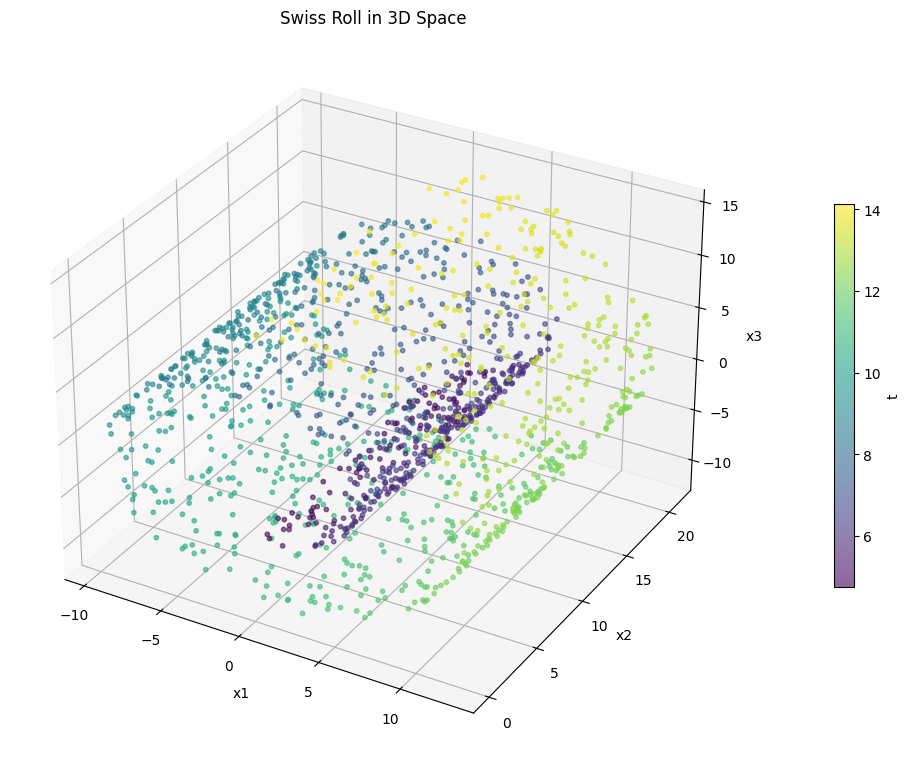

In [20]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=t_true, cmap='viridis', s=10, alpha=0.6)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
ax.set_title('Swiss Roll in 3D Space')
plt.colorbar(scatter, ax=ax, label='t', pad=0.1, shrink=0.5)

plt.tight_layout()
plt.savefig('../data/swiss_roll_3d.png', dpi=300)
plt.show()

## 1. VAE (Variational Autoencoder)


In [21]:
vae = VAE(
    input_dim=3,
    hidden_dim=50,
    latent_dim=2,
    likelihood=Likelihood.GAUSSIAN,
    epochs=300,
    batch_size=128,
    learning_rate=1e-3,
    verbose=True,
    random_state=42,
)

vae.fit(X_train)

2025-10-28 00:26:51.570 | INFO     | vaes.models.vae:fit:83 - Starting training (epochs=300)
Epoch 1: 100%|██████████| 10/10 [00:00<00:00, 872.60it/s, loss=3.5116, recon=3.4423, kl=0.0692]
2025-10-28 00:26:51.582 | INFO     | vaes.models.vae:fit:92 - Epoch 1/300 - Loss: 3.3661 (Recon: 3.2740, KL: 0.0921)
Epoch 2: 100%|██████████| 10/10 [00:00<00:00, 1010.43it/s, loss=3.0708, recon=3.0234, kl=0.0474]
2025-10-28 00:26:51.593 | INFO     | vaes.models.vae:fit:92 - Epoch 2/300 - Loss: 3.1233 (Recon: 3.0666, KL: 0.0567)
Epoch 3: 100%|██████████| 10/10 [00:00<00:00, 1059.89it/s, loss=2.8947, recon=2.8465, kl=0.0482]
2025-10-28 00:26:51.603 | INFO     | vaes.models.vae:fit:92 - Epoch 3/300 - Loss: 3.0176 (Recon: 2.9687, KL: 0.0488)
Epoch 4: 100%|██████████| 10/10 [00:00<00:00, 1037.99it/s, loss=2.9931, recon=2.9379, kl=0.0552]
2025-10-28 00:26:51.614 | INFO     | vaes.models.vae:fit:92 - Epoch 4/300 - Loss: 2.9830 (Recon: 2.9249, KL: 0.0581)
Epoch 5: 100%|██████████| 10/10 [00:00<00:00, 1018.0

### Training Curves


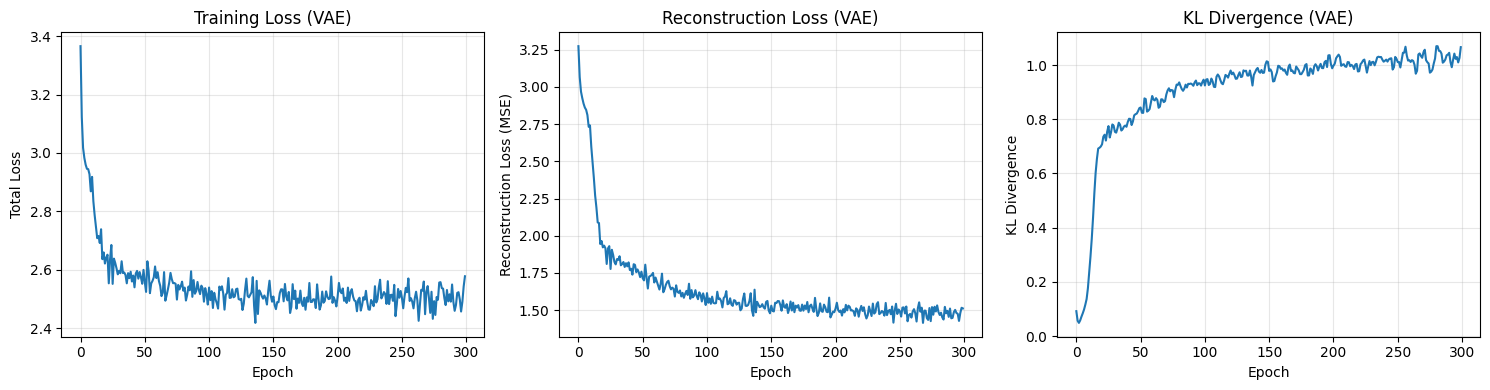

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(vae.history_['train_loss'])
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training Loss (VAE)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(vae.history_['train_recon'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss (MSE)')
axes[1].set_title('Reconstruction Loss (VAE)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(vae.history_['train_kl'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence (VAE)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/vae_gaussian_training_curves.png', dpi=300)
plt.show()

### Learned Latent Space Visualization


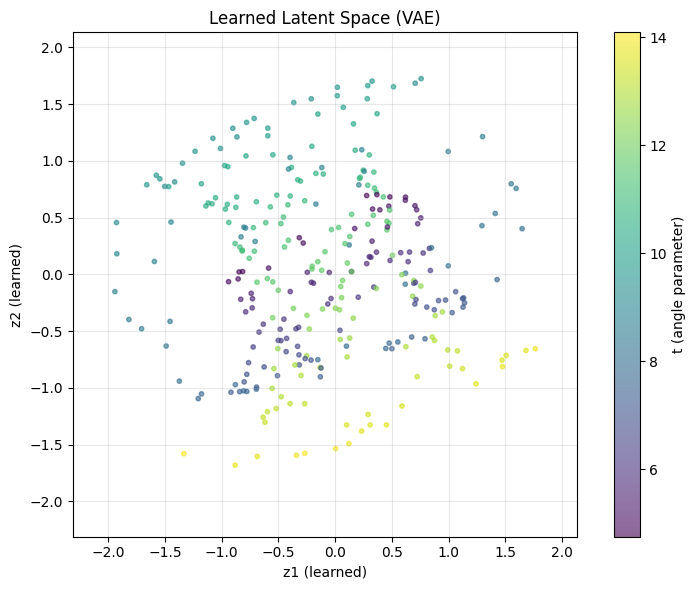

In [23]:
Z_encoded = vae.transform(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
plot_single_latent_space(
    ax, Z_encoded, t_test, 'z1 (learned)', 'z2 (learned)', 'Learned Latent Space (VAE)'
)
plt.colorbar(ax.collections[0], ax=ax, label='t (angle parameter)')

plt.tight_layout()
plt.savefig('../data/vae_gaussian_latent_space.png', dpi=300)
plt.show()

## 2. Beta-VAE


In [24]:
beta_vae = BetaVAE(
    input_dim=3,
    hidden_dim=50,
    latent_dim=2,
    likelihood=Likelihood.GAUSSIAN,
    beta=4.0,
    epochs=100,
    batch_size=128,
    learning_rate=1e-3,
    verbose=True,
    random_state=42,
)

beta_vae.fit(X_train)

2025-10-28 00:26:55.548 | INFO     | vaes.models.vae:fit:83 - Starting training (epochs=100)
Epoch 1: 100%|██████████| 10/10 [00:00<00:00, 946.26it/s, loss=3.6887, recon=3.4722, kl=0.0541]
2025-10-28 00:26:55.560 | INFO     | vaes.models.vae:fit:92 - Epoch 1/100 - Loss: 3.6186 (Recon: 3.2908, KL: 0.0819)
Epoch 2: 100%|██████████| 10/10 [00:00<00:00, 1003.30it/s, loss=3.1872, recon=3.0702, kl=0.0292]
2025-10-28 00:26:55.571 | INFO     | vaes.models.vae:fit:92 - Epoch 2/100 - Loss: 3.2564 (Recon: 3.1076, KL: 0.0372)
Epoch 3: 100%|██████████| 10/10 [00:00<00:00, 1031.68it/s, loss=2.9808, recon=2.9029, kl=0.0195]
2025-10-28 00:26:55.581 | INFO     | vaes.models.vae:fit:92 - Epoch 3/100 - Loss: 3.1112 (Recon: 3.0178, KL: 0.0233)
Epoch 4: 100%|██████████| 10/10 [00:00<00:00, 1081.31it/s, loss=3.0714, recon=3.0163, kl=0.0138]
2025-10-28 00:26:55.591 | INFO     | vaes.models.vae:fit:92 - Epoch 4/100 - Loss: 3.0640 (Recon: 2.9894, KL: 0.0186)
Epoch 5: 100%|██████████| 10/10 [00:00<00:00, 1069.2

### Training Curves


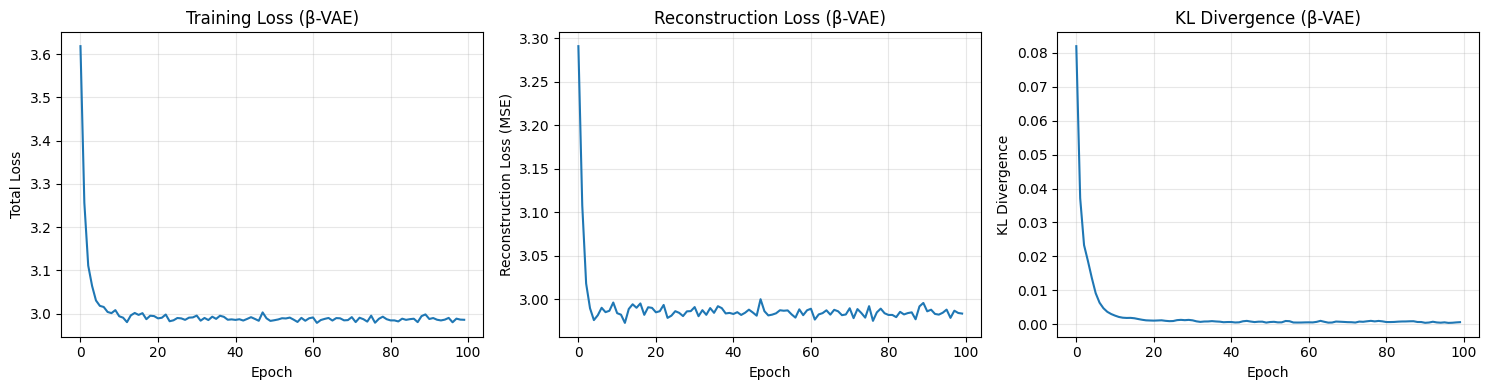

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(beta_vae.history_['train_loss'])
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training Loss (β-VAE)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(beta_vae.history_['train_recon'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss (MSE)')
axes[1].set_title('Reconstruction Loss (β-VAE)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(beta_vae.history_['train_kl'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence (β-VAE)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/beta_vae_gaussian_training_curves.png', dpi=300)
plt.show()

### Learned Latent Space Visualization


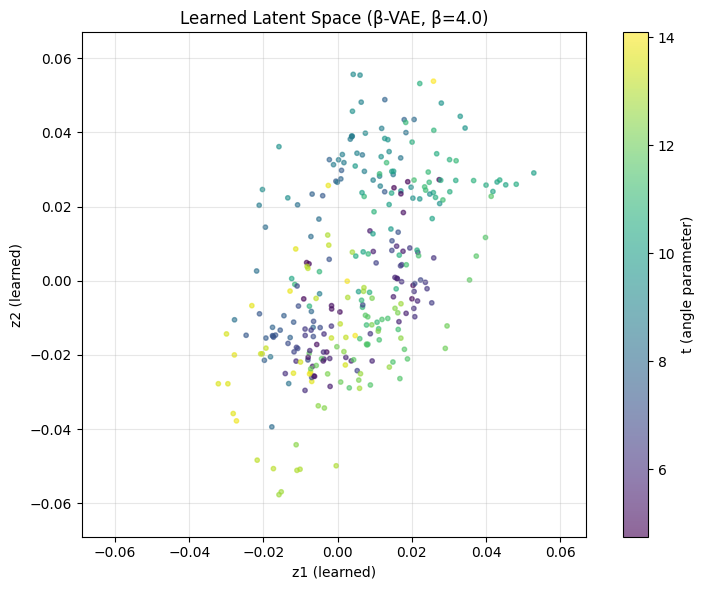

In [26]:
Z_encoded_beta = beta_vae.transform(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
plot_single_latent_space(
    ax,
    Z_encoded_beta,
    t_test,
    'z1 (learned)',
    'z2 (learned)',
    'Learned Latent Space (β-VAE, β=4.0)',
)
plt.colorbar(ax.collections[0], ax=ax, label='t (angle parameter)')

plt.tight_layout()
plt.savefig('../data/beta_vae_gaussian_latent_space.png', dpi=300)
plt.show()

## 3. Beta-TC-VAE


In [27]:
beta_tcvae = BetaTCVAE(
    input_dim=3,
    hidden_dim=50,
    latent_dim=2,
    likelihood=Likelihood.GAUSSIAN,
    alpha=1.0,
    beta=6.0,
    gamma=1.0,
    epochs=300,
    batch_size=128,
    learning_rate=1e-3,
    verbose=True,
    random_state=42,
)

beta_tcvae.fit(X_train)

2025-10-28 00:26:56.985 | INFO     | vaes.models.beta_tcvae:fit:132 - Starting training (epochs=300, α=1.0, β=6.0, γ=1.0)
Epoch 1: 100%|██████████| 10/10 [00:00<00:00, 444.88it/s, loss=3.4609, recon=3.3998, mi=0.0398, tc=0.0039, dwkl=-0.0019]
2025-10-28 00:26:57.009 | INFO     | vaes.models.beta_tcvae:fit:143 - Epoch 1/300 - Loss: 3.4231 (Recon: 3.3187, MI: 0.0463, TC: 0.0006, DW-KL: 0.0548)
Epoch 2: 100%|██████████| 10/10 [00:00<00:00, 497.09it/s, loss=3.2032, recon=3.1470, mi=0.0225, tc=0.0036, dwkl=0.0122]
2025-10-28 00:26:57.031 | INFO     | vaes.models.beta_tcvae:fit:143 - Epoch 2/300 - Loss: 3.1016 (Recon: 3.0439, MI: 0.0510, TC: -0.0009, DW-KL: 0.0121)
Epoch 3: 100%|██████████| 10/10 [00:00<00:00, 455.62it/s, loss=3.0834, recon=3.0140, mi=0.0734, tc=-0.0014, dwkl=0.0042]
2025-10-28 00:26:57.054 | INFO     | vaes.models.beta_tcvae:fit:143 - Epoch 3/300 - Loss: 3.0043 (Recon: 2.9592, MI: 0.0382, TC: 0.0002, DW-KL: 0.0059)
Epoch 4: 100%|██████████| 10/10 [00:00<00:00, 503.06it/s, l

### Training Curves


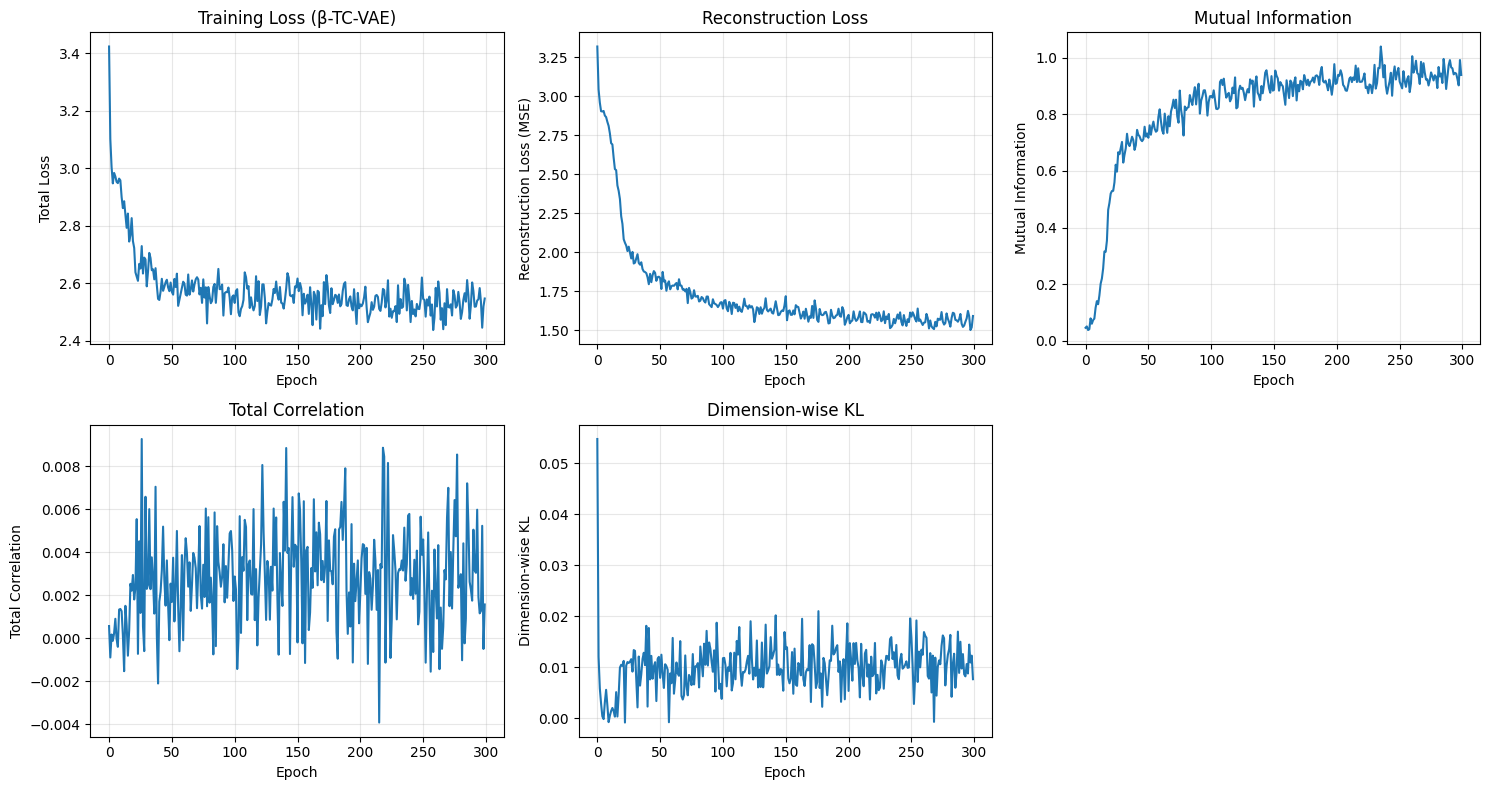

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].plot(beta_tcvae.history_['train_loss'])
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Training Loss (β-TC-VAE)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(beta_tcvae.history_['train_recon'])
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Reconstruction Loss (MSE)')
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(beta_tcvae.history_['train_kl'])
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Mutual Information')
axes[0, 2].set_title('Mutual Information')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].plot(beta_tcvae.history_['train_tc'])
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Total Correlation')
axes[1, 0].set_title('Total Correlation')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(beta_tcvae.history_['train_dwkl'])
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Dimension-wise KL')
axes[1, 1].set_title('Dimension-wise KL')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('../data/beta_tcvae_gaussian_training_curves.png', dpi=300)
plt.show()

### Learned Latent Space Visualization


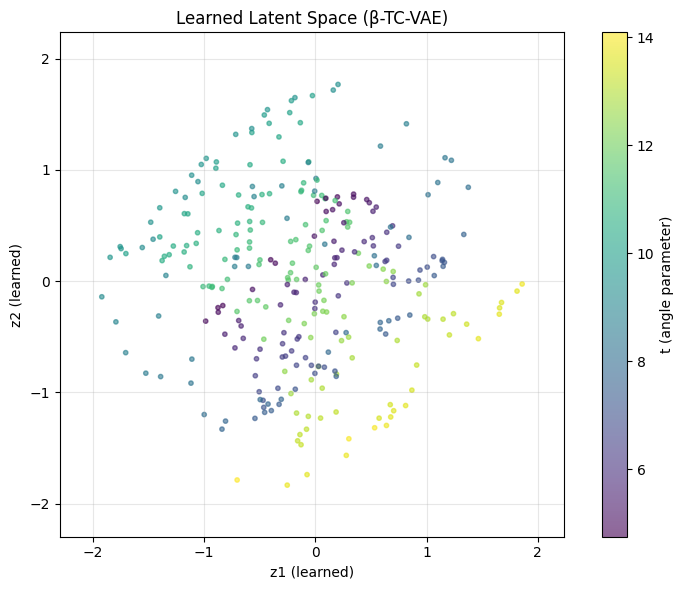

In [29]:
Z_encoded_btcvae = beta_tcvae.transform(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
plot_single_latent_space(
    ax,
    Z_encoded_btcvae,
    t_test,
    'z1 (learned)',
    'z2 (learned)',
    'Learned Latent Space (β-TC-VAE)',
)
plt.colorbar(ax.collections[0], ax=ax, label='t (angle parameter)')

plt.tight_layout()
plt.savefig('../data/beta_tcvae_gaussian_latent_space.png', dpi=300)
plt.show()

## 4. Sparse VAE


In [30]:
sparse_vae = SparseVAE(
    input_dim=3,
    hidden_dim=50,
    latent_dim=2,
    likelihood=Likelihood.GAUSSIAN,
    sparsity_prior=0.5,
    beta=1.0,
    epochs=1000,
    batch_size=128,
    learning_rate=1e-3,
    verbose=True,
    random_state=42,
)

sparse_vae.fit(X_train)

2025-10-28 00:27:04.462 | INFO     | vaes.models.sparse_vae:fit:90 - Starting training (epochs=1000, sparsity_prior=0.5)
Epoch 1: 100%|██████████| 10/10 [00:00<00:00, 595.74it/s, loss=2.9666, recon=2.9174, kl_z=0.0377, kl_s=0.0115]
2025-10-28 00:27:04.480 | INFO     | vaes.models.sparse_vae:fit:102 - Epoch 1/1000 - Loss: 3.1763 (Recon: 3.0992, KL_z: 0.0572, KL_s: 0.0199)
Epoch 2: 100%|██████████| 10/10 [00:00<00:00, 504.39it/s, loss=3.1025, recon=3.0729, kl_z=0.0244, kl_s=0.0051]
2025-10-28 00:27:04.503 | INFO     | vaes.models.sparse_vae:fit:102 - Epoch 2/1000 - Loss: 3.0621 (Recon: 3.0234, KL_z: 0.0292, KL_s: 0.0095)
Epoch 3: 100%|██████████| 10/10 [00:00<00:00, 607.20it/s, loss=2.7627, recon=2.7379, kl_z=0.0200, kl_s=0.0048]
2025-10-28 00:27:04.520 | INFO     | vaes.models.sparse_vae:fit:102 - Epoch 3/1000 - Loss: 2.9935 (Recon: 2.9678, KL_z: 0.0205, KL_s: 0.0052)
Epoch 4: 100%|██████████| 10/10 [00:00<00:00, 814.32it/s, loss=3.1636, recon=3.1355, kl_z=0.0235, kl_s=0.0045]
2025-10-2

### Training Curves


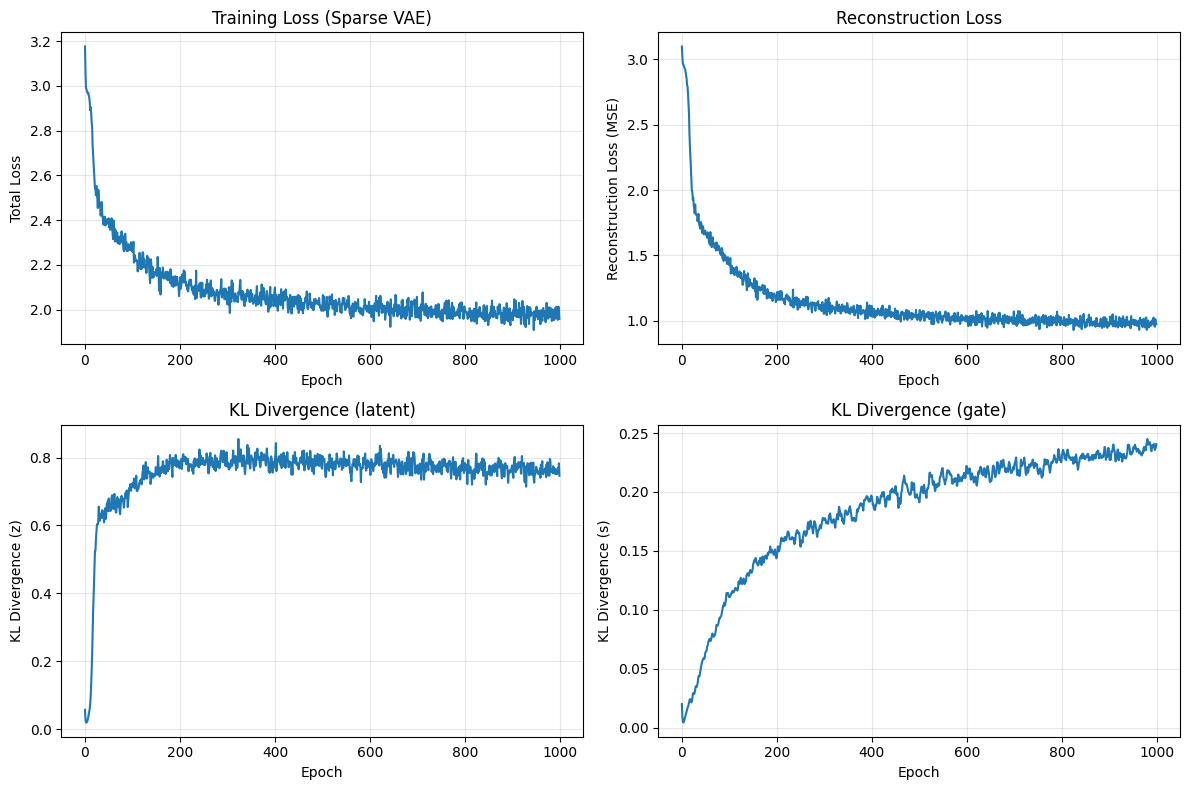

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(sparse_vae.history_['train_loss'])
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Training Loss (Sparse VAE)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(sparse_vae.history_['train_recon'])
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Reconstruction Loss (MSE)')
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(sparse_vae.history_['train_kl_z'])
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('KL Divergence (z)')
axes[1, 0].set_title('KL Divergence (latent)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(sparse_vae.history_['train_kl_s'])
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('KL Divergence (s)')
axes[1, 1].set_title('KL Divergence (gate)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/sparse_vae_gaussian_training_curves.png', dpi=300)
plt.show()

### Sparsity Analysis


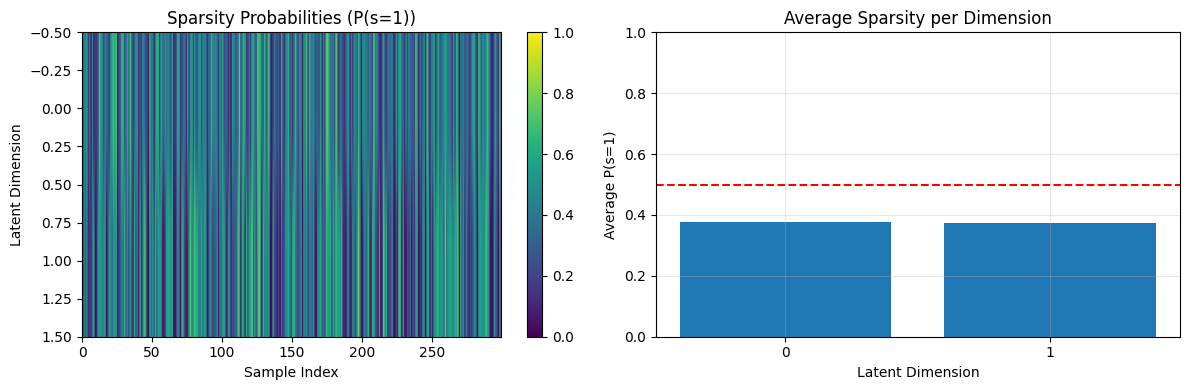

Average sparsity: 0.376
Number of active dimensions (P(s=1) > 0.5): 0/2


In [32]:
sparsity_probs = sparse_vae.get_sparsity(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(sparsity_probs.T, aspect='auto', cmap='viridis', vmin=0, vmax=1)
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Latent Dimension')
axes[0].set_title('Sparsity Probabilities (P(s=1))')
plt.colorbar(im, ax=axes[0])

avg_sparsity = sparsity_probs.mean(axis=0)
axes[1].bar(range(len(avg_sparsity)), avg_sparsity)
axes[1].axhline(y=0.5, color='r', linestyle='--')
axes[1].set_xlabel('Latent Dimension')
axes[1].set_ylabel('Average P(s=1)')
axes[1].set_title('Average Sparsity per Dimension')
axes[1].set_ylim([0, 1])
axes[1].set_xticks(range(len(avg_sparsity)))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/sparse_vae_gaussian_sparsity.png', dpi=300)
plt.show()

print(f'Average sparsity: {sparsity_probs.mean():.3f}')
print(
    f'Number of active dimensions (P(s=1) > 0.5): {(avg_sparsity > 0.5).sum()}/{len(avg_sparsity)}'
)

### Learned Latent Space Visualization


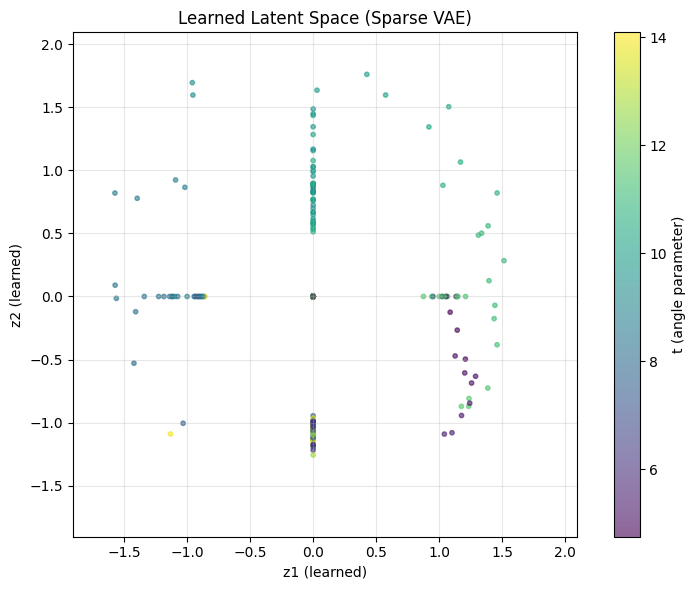

In [33]:
Z_encoded_sparse = sparse_vae.transform(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
plot_single_latent_space(
    ax,
    Z_encoded_sparse,
    t_test,
    'z1 (learned)',
    'z2 (learned)',
    'Learned Latent Space (Sparse VAE)',
)
plt.colorbar(ax.collections[0], ax=ax, label='t (angle parameter)')

plt.tight_layout()
plt.savefig('../data/sparse_vae_gaussian_latent_space.png', dpi=300)
plt.show()

## 5. Model Comparison


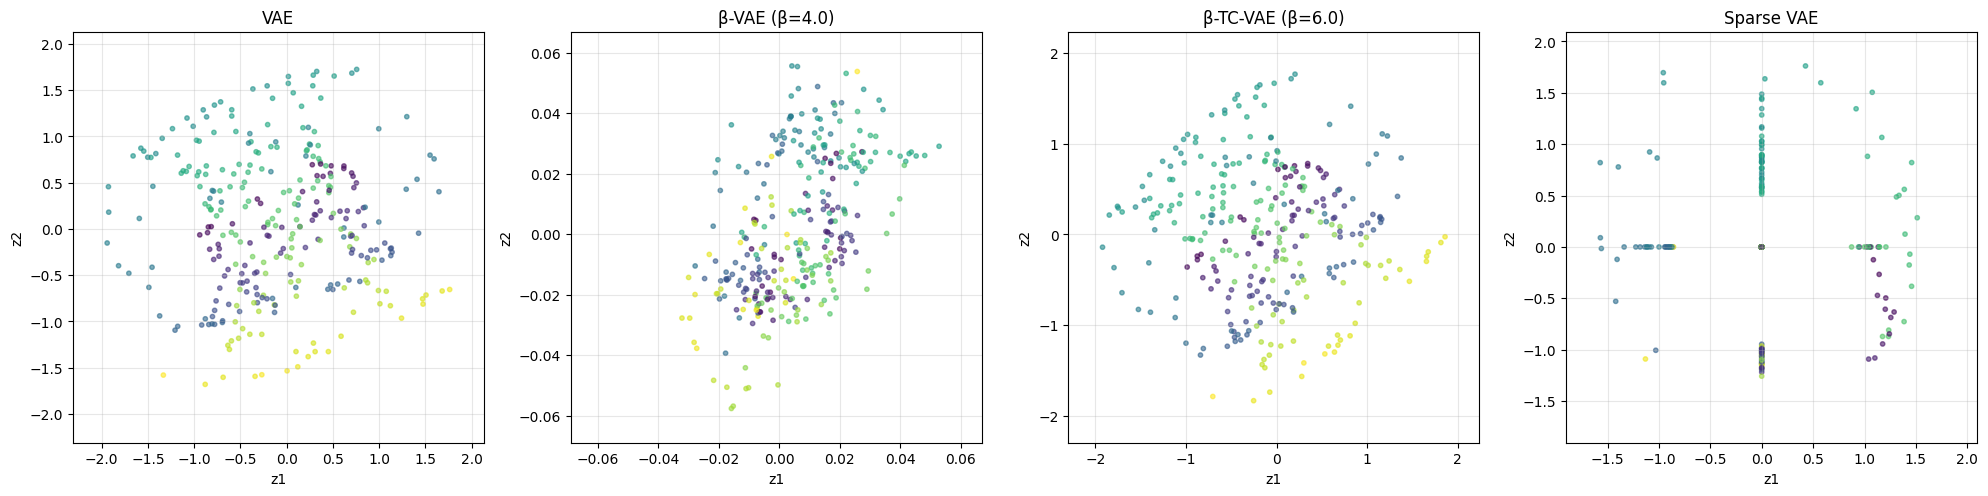

In [34]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

plot_single_latent_space(axes[0], Z_encoded, t_test, 'z1', 'z2', 'VAE')
plot_single_latent_space(axes[1], Z_encoded_beta, t_test, 'z1', 'z2', 'β-VAE (β=4.0)')
plot_single_latent_space(axes[2], Z_encoded_btcvae, t_test, 'z1', 'z2', 'β-TC-VAE (β=6.0)')
plot_single_latent_space(axes[3], Z_encoded_sparse, t_test, 'z1', 'z2', 'Sparse VAE')

plt.tight_layout()
plt.savefig('../data/model_comparison_gaussian.png', dpi=300)
plt.show()